In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
assert (PROJECT_ROOT / "src").exists(), "src NOT FOUND — WRONG ROOT"

sys.path.insert(0, str(PROJECT_ROOT))

print(" Project root added:", PROJECT_ROOT)


✅ Project root added: d:\projects\CreditPathAI_Oct_Batch


In [24]:
from src.utils import print_tree
print_tree(PROJECT_ROOT  , depth=1)


CreditPathAI_Oct_Batch/
    .git/
        COMMIT_EDITMSG
        config
        description
        FETCH_HEAD
        HEAD
        index
        ORIG_HEAD
        packed-refs
    .gitattributes
    .gitignore
    .venv/
        .gitignore
        pyvenv.cfg
    artifacts/
    CreditPathAI_Oct_Batch/
    git
    kaggle_dataset/
        .gitignore
        README.md
        requirements.txt
    LICENSE
    main.py
    microsoft_dataset/
        microsoft_main.ipynb
    README.md
    requirements.txt
    src/
        eda.py
        evaluate.py
        inference.py
        ingestion.py
        models.py
        preprocess.py
        utils.py
        __init__.py
    streamlit/
        streamlit_app.py


In [25]:

from src.eda import *


import pandas as pd

data_path = project_root / "microsoft_dataset" / "data" / "interim" / "merged_loan_borrower.csv"
df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()


Shape: (100000, 28)


,memberId,residentialState,yearsEmployment,homeOwnership,annualIncome,incomeVerified,dtiRatio,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,...,date,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,loanStatus,defaultFlag
0,2305095,NM,10+ years,rent,56471,1,16.80,6,11,9.0,...,12/10/2014,debtconsolidation,0.0,25190.0,60 months,6.25,490,E3,Current,0
1,2610493,WA,2-5 years,rent,55038,0,19.99,22,8,7.0,...,9/15/2014,debtconsolidation,0.0,21189.0,60 months,10.49,455,B3,Current,0
2,2491679,MS,< 1 year,rent,56610,1,14.33,5,8,5.0,...,9/11/2014,debtconsolidation,0.0,29908.0,60 months,9.11,622,B2,Current,0
3,2092798,TX,6-9 years,own,54887,1,14.80,12,14,7.0,...,4/22/2016,homeimprovement,0.0,13053.0,48 months,11.89,343,B3,Current,0
4,2633077,MA,2-5 years,rent,53522,1,10.14,4,21,19.0,...,2/3/2016,debtconsolidation,0.0,24613.0,60 months,15.13,587,A3,Current,0


In [26]:

from src.eda import dataset_overview

dataset_overview(df)


 DATASET OVERVIEW
Shape: (100000, 28)

Columns:
 ['memberId', 'residentialState', 'yearsEmployment', 'homeOwnership', 'annualIncome', 'incomeVerified', 'dtiRatio', 'lengthCreditHistory', 'numTotalCreditLines', 'numOpenCreditLines', 'numOpenCreditLines1Year', 'revolvingBalance', 'revolvingUtilizationRate', 'numDerogatoryRec', 'numDelinquency2Years', 'numChargeoff1year', 'numInquiries6Mon', 'loanId', 'date', 'purpose', 'isJointApplication', 'loanAmount', 'term', 'interestRate', 'monthlyPayment', 'grade', 'loanStatus', 'defaultFlag']

Data Types:
 memberId                      int64
residentialState             object
yearsEmployment              object
homeOwnership                object
annualIncome                  int64
incomeVerified                int64
dtiRatio                    float64
lengthCreditHistory           int64
numTotalCreditLines           int64
numOpenCreditLines          float64
numOpenCreditLines1Year       int64
revolvingBalance              int64
revolvingUtiliza


 MISSING VALUES SUMMARY:
 term                  1071
loanAmount            1006
isJointApplication     971
numOpenCreditLines     967
dtype: int64


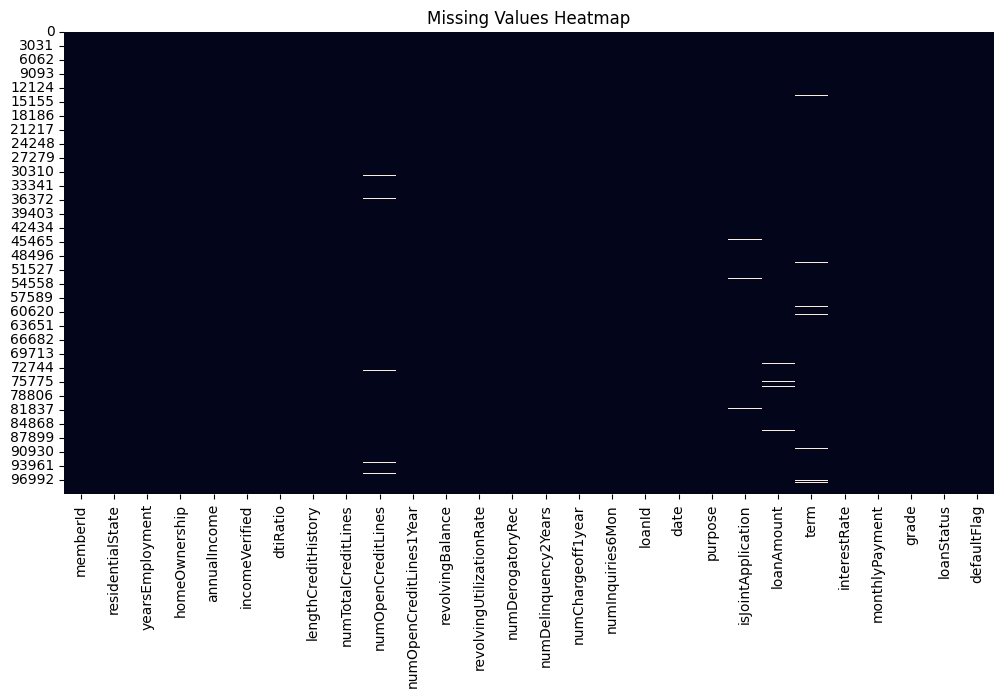

In [27]:
missing_values_analysis(df)

In [28]:
outlier_detection(df)


 OUTLIERS PER COLUMN:
 numDerogatoryRec            18302
numDelinquency2Years        15073
numChargeoff1year           13499
numInquiries6Mon            11234
defaultFlag                 10004
lengthCreditHistory          8665
isJointApplication           4968
monthlyPayment               1138
interestRate                 1057
annualIncome                 1014
numOpenCreditLines1Year       916
numOpenCreditLines            852
loanAmount                    850
dtiRatio                      686
revolvingBalance              638
revolvingUtilizationRate      315
numTotalCreditLines           196
memberId                        0
incomeVerified                  0
loanId                          0
dtype: int64


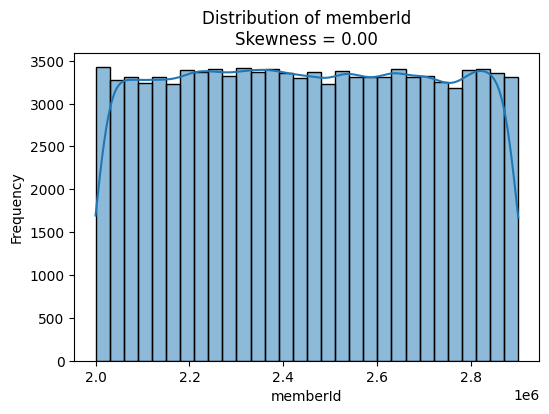

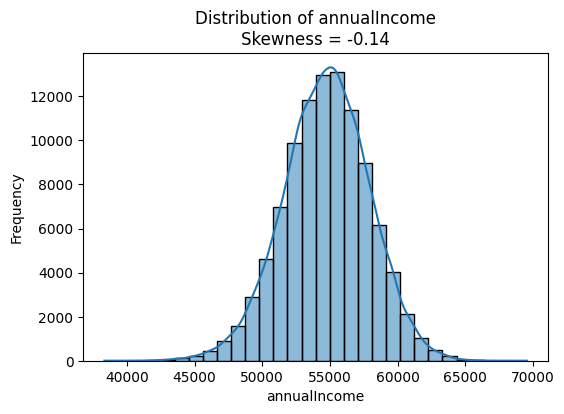

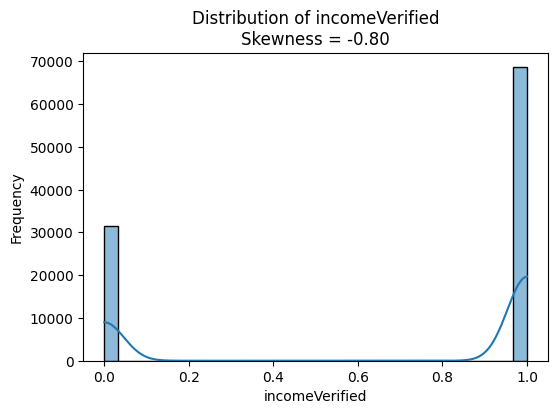

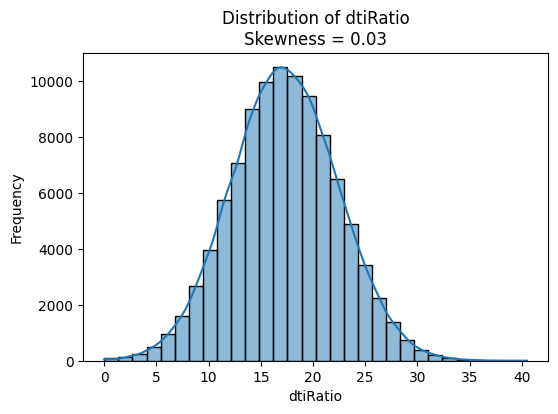

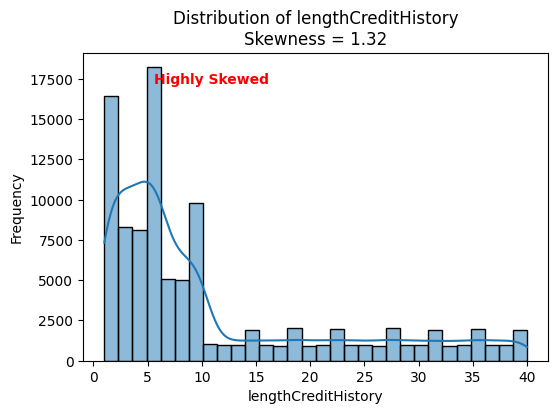

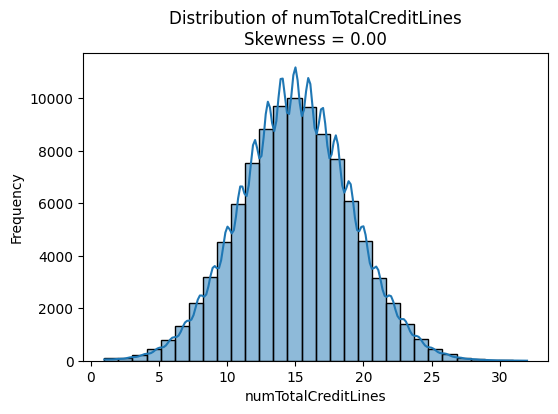

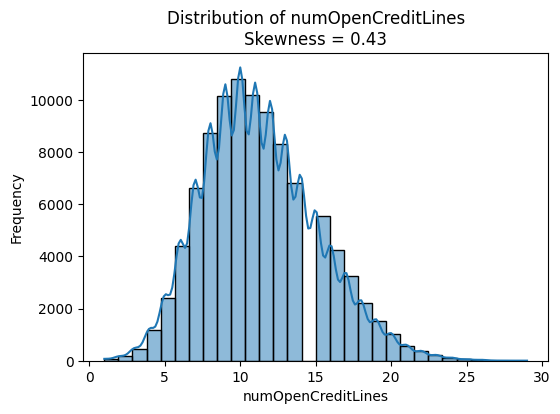

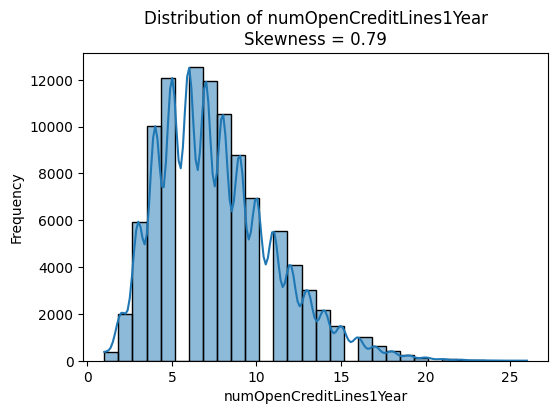

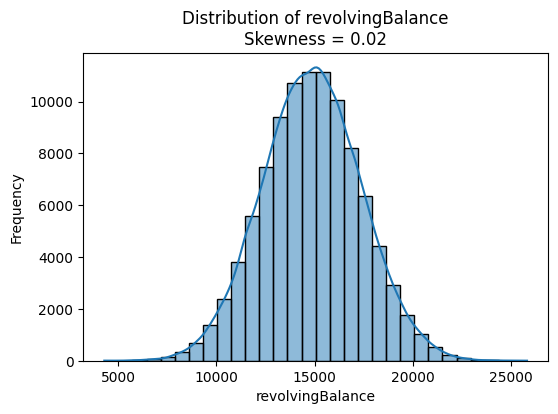

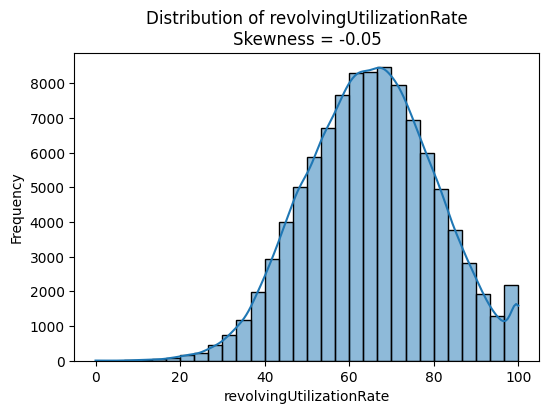

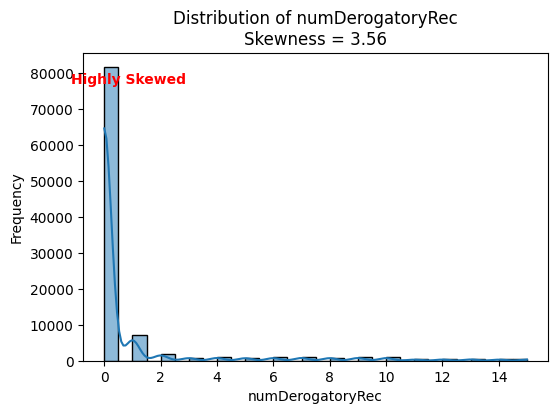

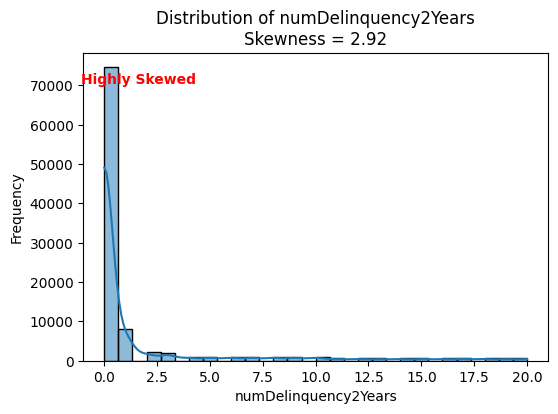

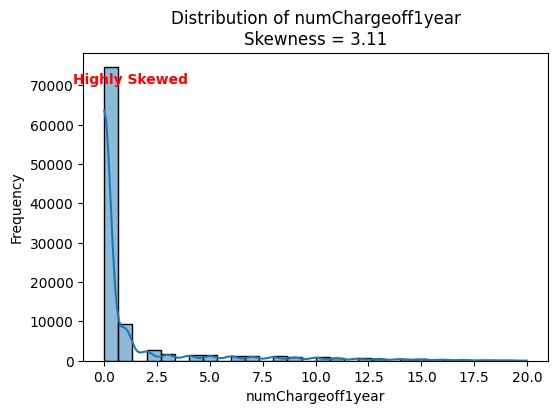

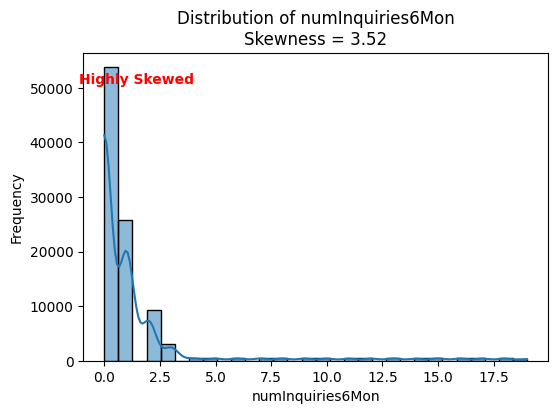

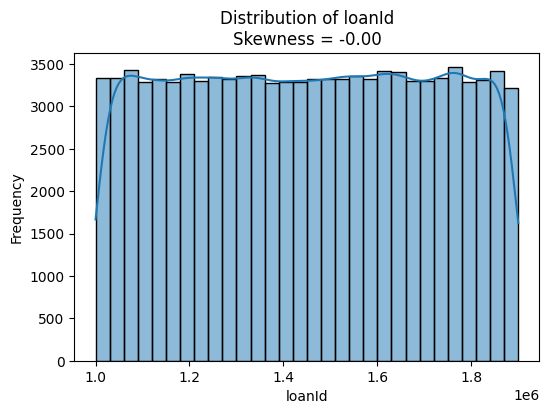

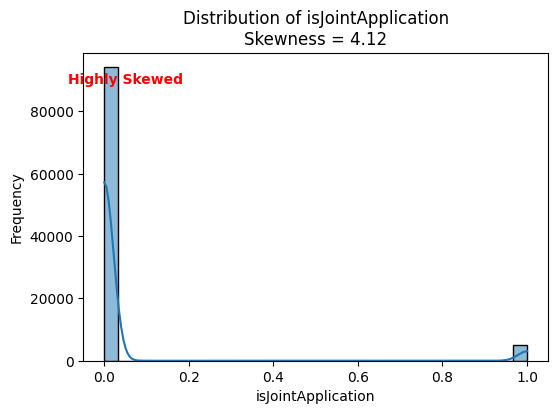

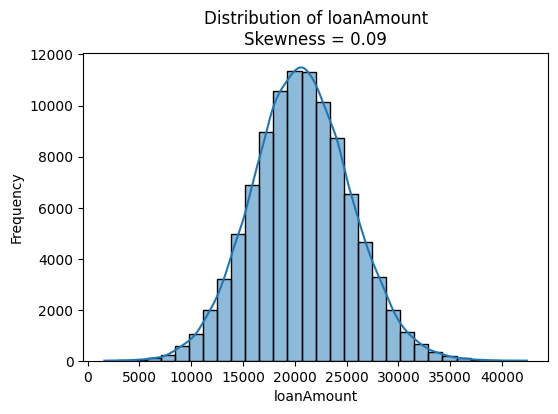

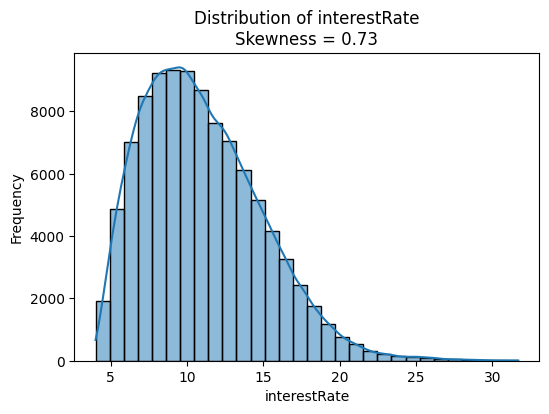

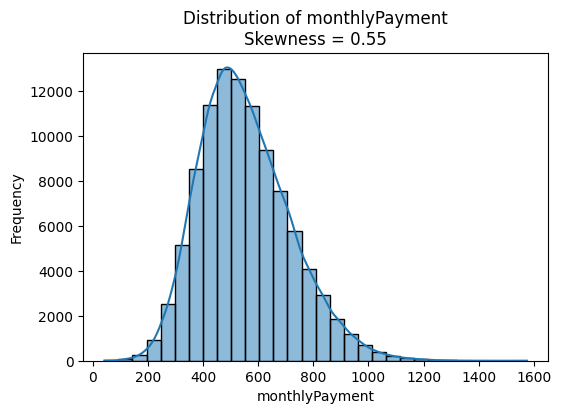

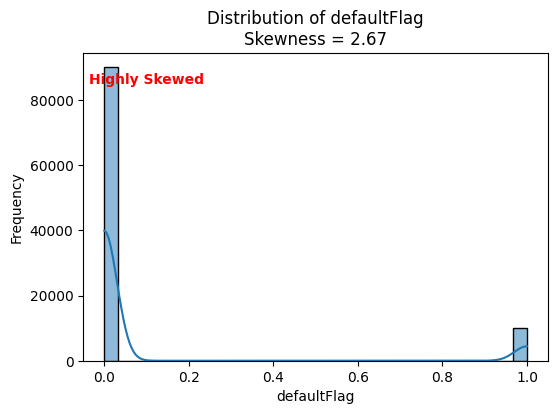

In [29]:

plt.show(univariate_numeric(df))

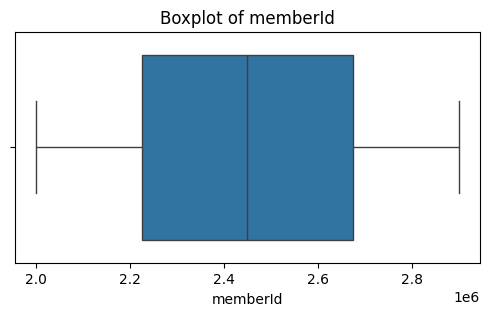

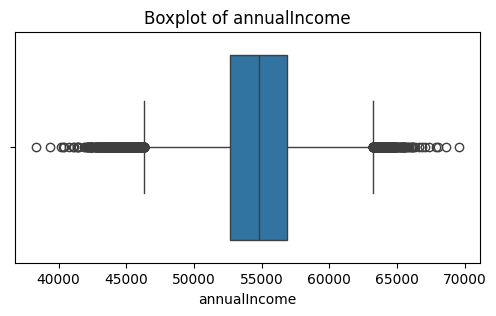

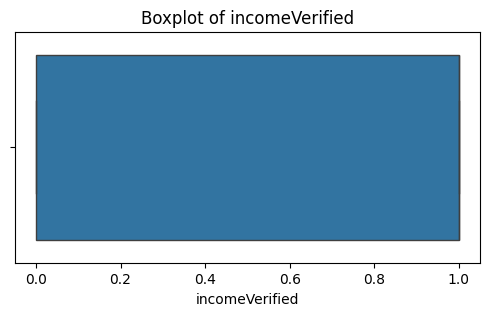

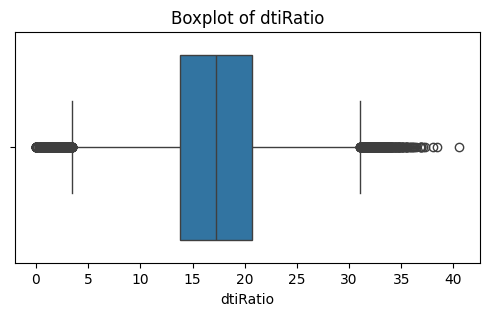

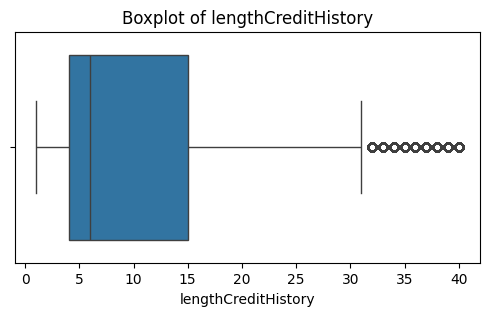

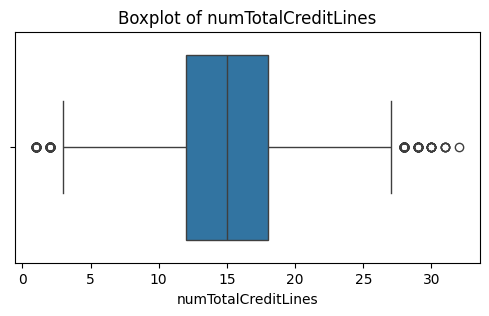

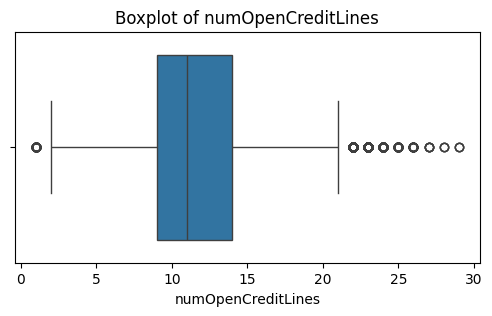

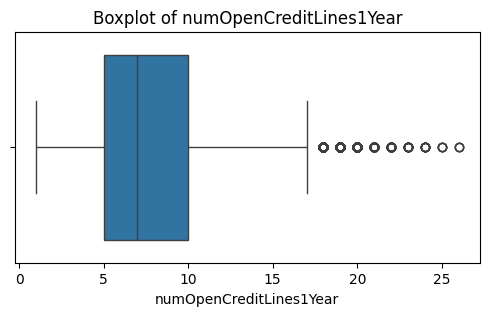

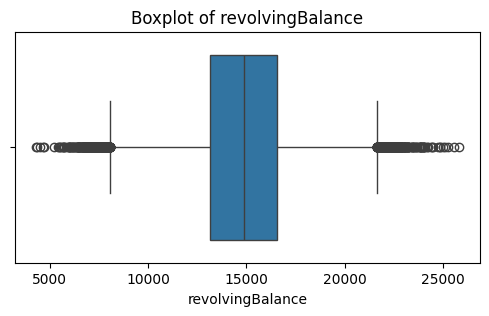

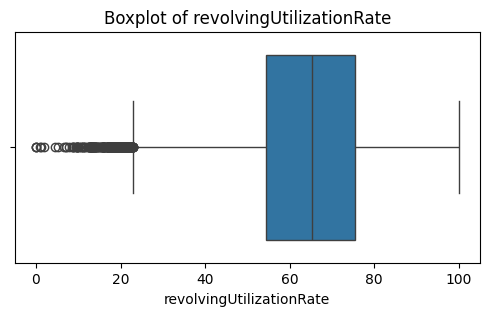

In [30]:
boxplots_numeric(df)

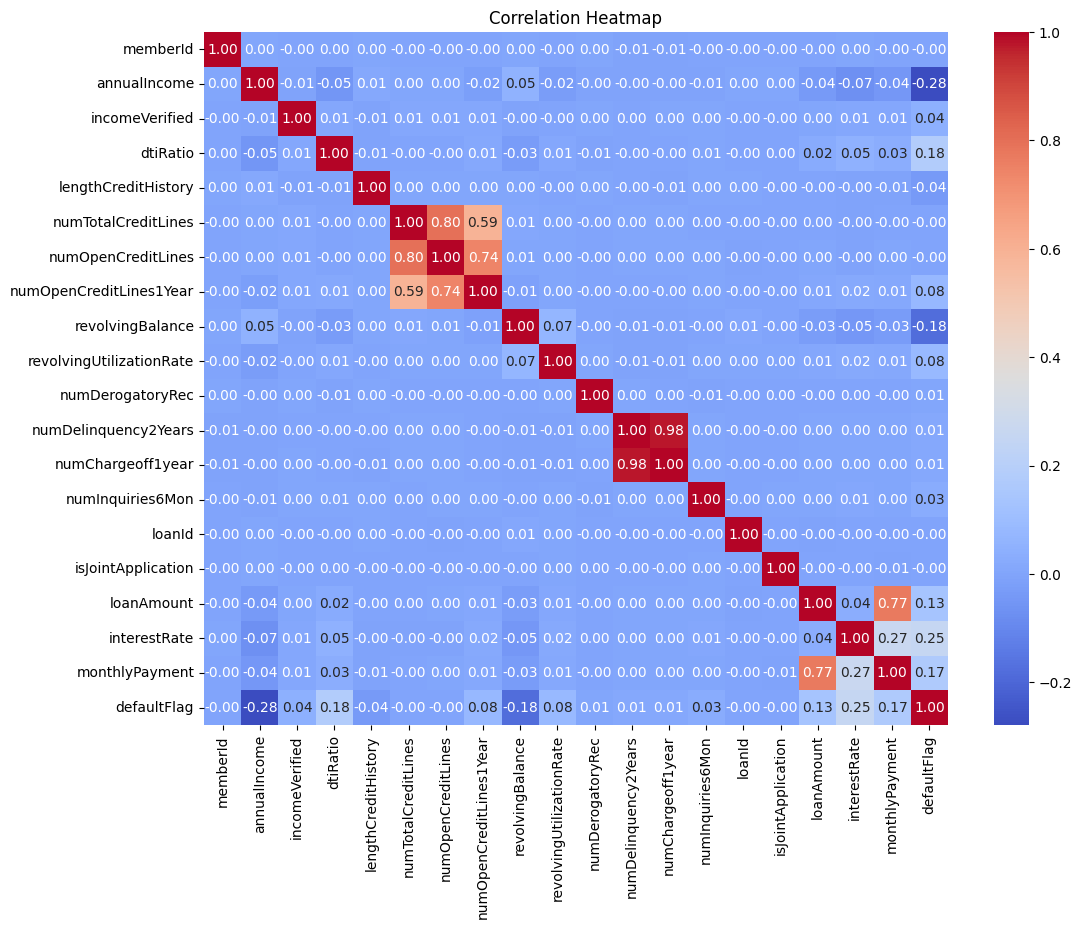

In [31]:
correlation_analysis(df)


 residentialState VALUE COUNTS:
 residentialState
CA    7057
FL    6603
DC    5396
NY    5161
WA    3477
TX    3432
IA    2975
IL    2913
ID    2845
IN    2800
RI    1790
NV    1771
GA    1767
KS    1755
MN    1751
SD    1745
MD    1744
MI    1741
SC    1738
LA    1732
ME    1728
NH    1725
MO    1718
MS    1709
TN    1707
MA    1694
NJ    1694
NE    1688
PA    1674
KY    1664
MT    1661
OR    1659
NM    1644
DE    1609
CT    1605
CO    1575
AR    1486
AL    1484
AZ    1467
OH     946
WV     907
NC     901
VA     874
UT     845
VT     843
OK     843
WI     833
WY     818
ND     806
Name: count, dtype: int64


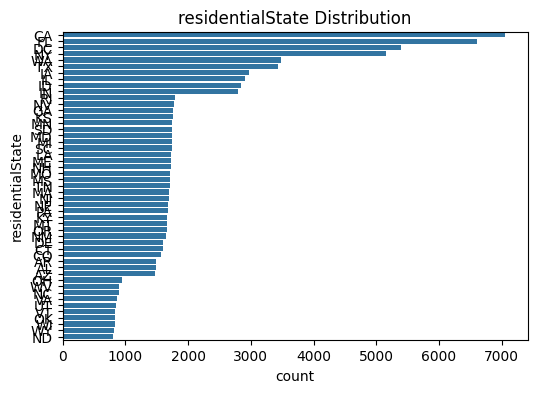


 yearsEmployment VALUE COUNTS:
 yearsEmployment
10+ years    22389
6-9 years    19945
< 1 year     19401
1 year       19211
2-5 years    19054
Name: count, dtype: int64


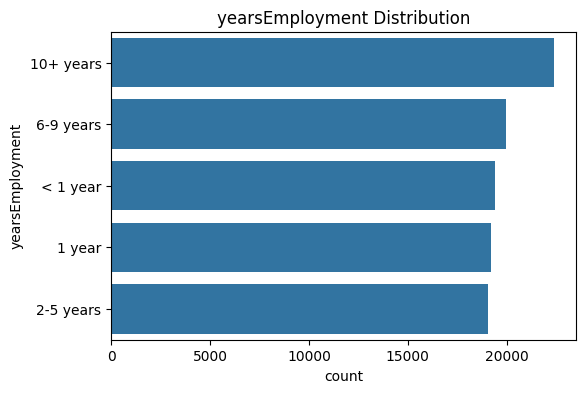


 homeOwnership VALUE COUNTS:
 homeOwnership
mortgage    36187
rent        32797
own         31016
Name: count, dtype: int64


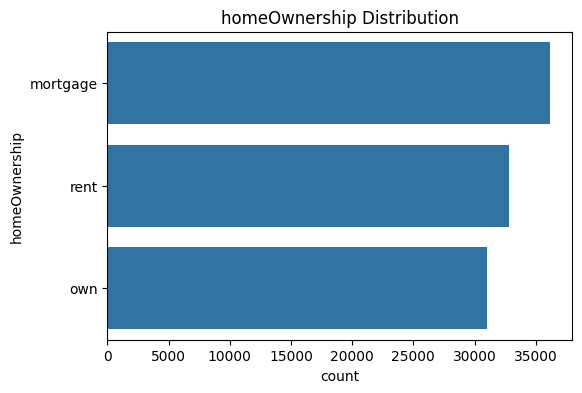


 date VALUE COUNTS:
 date
12/20/2015    162
12/15/2015    161
6/5/2015      160
4/18/2015     160
3/20/2016     160
             ... 
3/13/2016      99
1/19/2015      98
2/17/2016      97
5/14/2016      97
9/13/2015      96
Name: count, Length: 780, dtype: int64


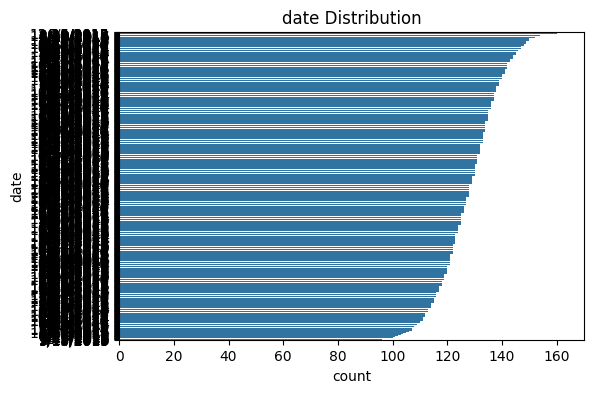


 purpose VALUE COUNTS:
 purpose
debtconsolidation    81344
homeimprovement       8116
other                 4118
business              3210
healthcare            1229
education             1003
auto                   980
Name: count, dtype: int64


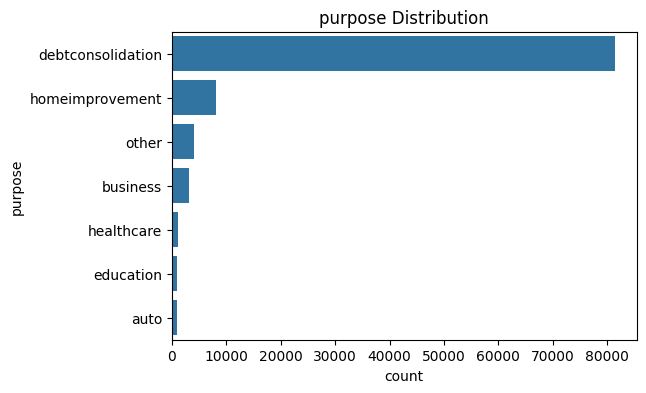


 term VALUE COUNTS:
 term
60 months    33971
48 months    32486
36 months    32472
Name: count, dtype: int64


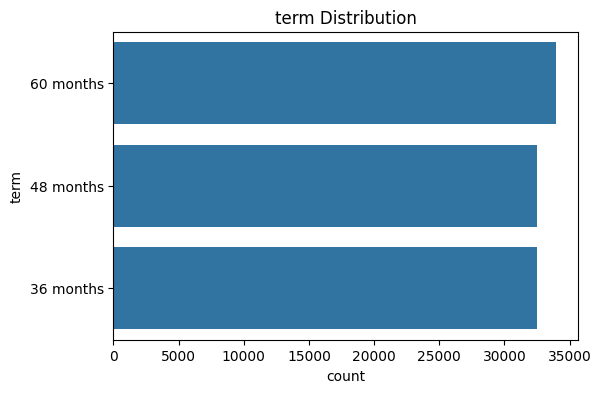


 grade VALUE COUNTS:
 grade
A1    11251
A2    10574
A3    10416
B1     8553
B3     8279
B2     8014
C1     7030
C2     6826
C3     5573
D2     4513
D1     4488
D3     3917
E3     3614
E1     3530
E2     3422
Name: count, dtype: int64


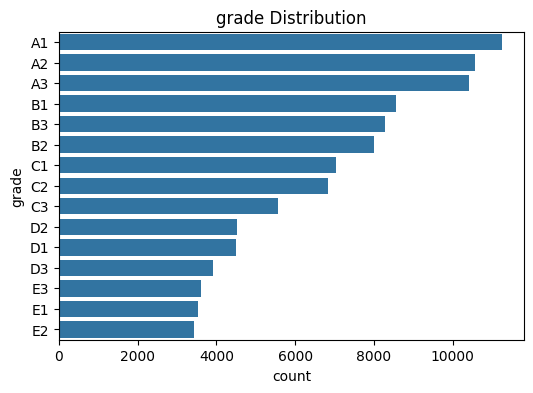


 loanStatus VALUE COUNTS:
 loanStatus
Current    89996
Default    10004
Name: count, dtype: int64


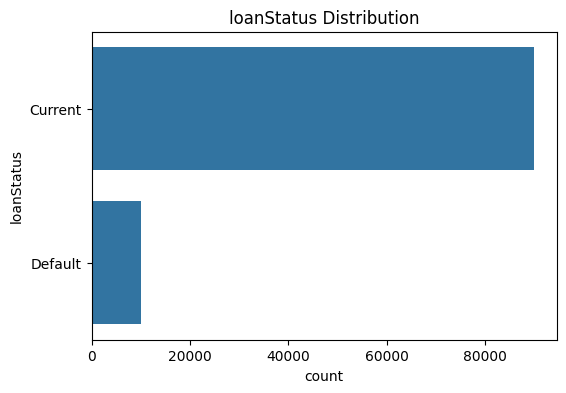

In [32]:
categorical_analysis(df,target_col='repay_fail')

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   memberId                  100000 non-null  int64  
 1   residentialState          100000 non-null  object 
 2   yearsEmployment           100000 non-null  object 
 3   homeOwnership             100000 non-null  object 
 4   annualIncome              100000 non-null  int64  
 5   incomeVerified            100000 non-null  int64  
 6   dtiRatio                  100000 non-null  float64
 7   lengthCreditHistory       100000 non-null  int64  
 8   numTotalCreditLines       100000 non-null  int64  
 9   numOpenCreditLines        99033 non-null   float64
 10  numOpenCreditLines1Year   100000 non-null  int64  
 11  revolvingBalance          100000 non-null  int64  
 12  revolvingUtilizationRate  100000 non-null  float64
 13  numDerogatoryRec          100000 non-null  in

In [34]:
target_analysis(df,target_col='loan_status')


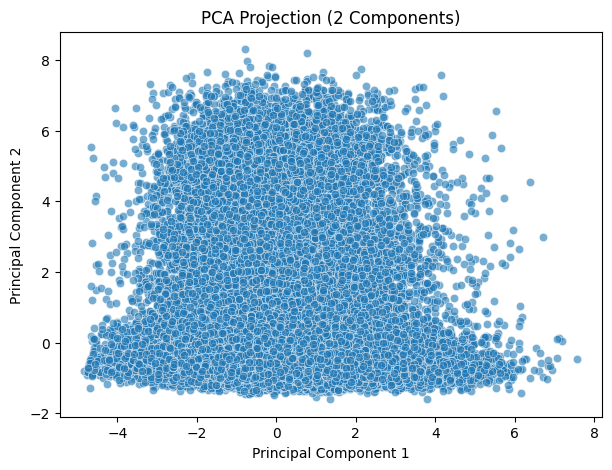

In [36]:
pca_analysis(df)
